## 习题 1-4
生成一个随机 $100\times 100$ 矩阵，即矩阵各元素都从正态分布中采样得到。

要求：

1. 计算该矩阵的 SVD，并绘制奇异值；
2. 将这一过程重复 100 次，并用箱线图展示奇异值分布；
3. 将奇异值的均值与中位数表示为 $r$ 的函数并作图。

随后，对不同矩阵规模重复上述实验，例如：

- $50\times 50$
- $200\times 200$
- $500\times 500$
- $1000\times 1000$

等等。

In [1]:
import numpy as np
import matplotlib.pyplot as plt


Task1: 生成一个随机 $100\times 100$ 矩阵，即矩阵各元素都从正态分布中采样得到。

In [2]:
A = np.random.randn(100, 100)
A

array([[-0.60971486, -0.89366089,  0.18785988, ...,  0.62372958,
        -0.57835992,  0.09060106],
       [ 2.10967323, -0.81905853, -0.26657677, ..., -0.18256082,
        -2.43214869, -0.16617757],
       [-0.62945781,  1.26153242,  0.97835932, ...,  0.11928432,
        -0.98325077,  0.00547023],
       ...,
       [-2.61901114, -0.78698085,  0.47121134, ...,  0.14361059,
         1.43737888, -0.41212797],
       [ 0.07732805,  0.41354666, -0.77606007, ...,  0.0988068 ,
         0.79366459, -0.34681558],
       [ 0.58270191, -0.08908079, -0.59407647, ..., -0.81235883,
        -0.14664673,  0.64632882]], shape=(100, 100))

Task2.1:计算该矩阵的 SVD，并绘制奇异值

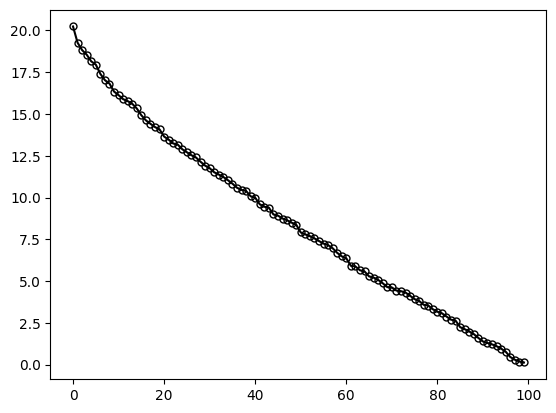

In [3]:
U, Sigma, V_T = np.linalg.svd(A,full_matrices=False)
plt.plot(Sigma,'-o',color = 'black',markersize = 5,markerfacecolor='none')
plt.show()

Task2.2 将这一过程重复 100 次，并用箱线图展示奇异值分布；


In [4]:
Sigma_all_data = np.zeros([100,100])
for i in range(100):
    A = np.random.randn(100, 100)
    U, Sigma, V_T = np.linalg.svd(A,full_matrices=False)
    Sigma_all_data[i,:] = Sigma


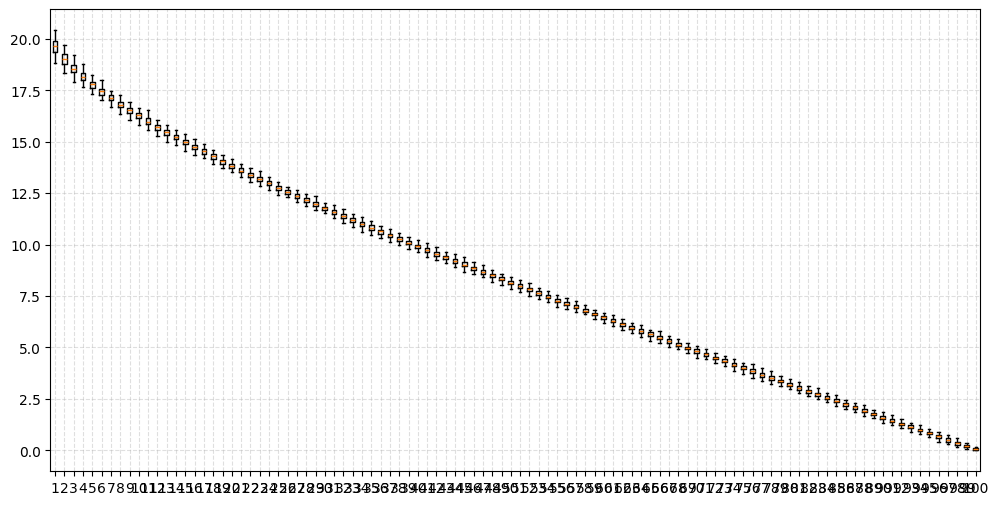

In [5]:
plt.figure(figsize=(12, 6))
plt.boxplot(Sigma_all_data,showfliers=False)
plt.grid(True,linestyle = '--',alpha=0.4)
plt.show()

Task2.3 将奇异值的均值与中位数表示为 $r$ 的函数并作图。

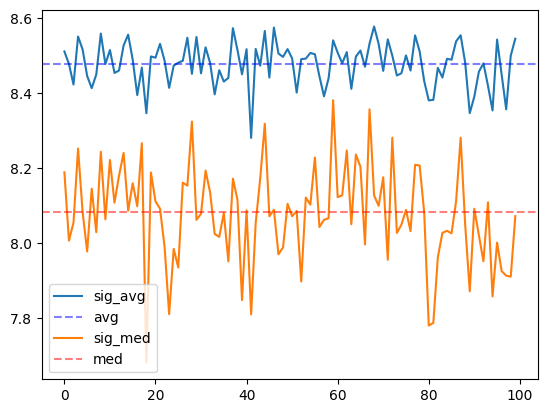

In [6]:
sig_avg = np.average(Sigma_all_data,axis=1)
r_avg = np.average(sig_avg)
sig_med = np.median(Sigma_all_data,axis=1)
r_med = np.median(sig_med)
plt.plot(sig_avg,label = 'sig_avg')
plt.axhline(y=r_avg,linestyle = '--',color = 'blue',alpha = 0.5,label='avg')
plt.plot(sig_med,label = 'sig_med')
plt.axhline(y=r_med,linestyle = '--',color = 'red',alpha = 0.5,label='med')
plt.legend(loc='best')
plt.show()

Task3: 对不同矩阵规模重复上述实验